# **1. Bag Of Words**

Example of spam/not spam email

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [3]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [4]:
df=pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df["spam"]=df["Category"].apply(lambda x:1 if x=='spam' else 0)
df.head(5)

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
print(df['spam'].value_counts())
print("\nShape is:" ,df.shape)

spam
0    4825
1     747
Name: count, dtype: int64

Shape is: (5572, 3)


In [8]:
X_train , X_test , y_train , y_test = train_test_split(df.Message , df.spam , test_size=0.3)

In [9]:
type(X_train)

pandas.core.series.Series

In [10]:
pipe =Pipeline([
    ("vectorizer",CountVectorizer()),
    ("nb",MultinomialNB())
])

pipe.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [11]:
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

pipe.predict(emails)

array([0, 1])

In [12]:
y_pred=pipe.predict(X_test)
result=classification_report(y_test,y_pred)
print(result)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1448
           1       0.96      0.92      0.94       224

    accuracy                           0.98      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.98      0.98      0.98      1672



In [13]:
accuracy_score=pipe.score(X_test,y_test)
print(accuracy_score)

0.9844497607655502


# **2. Bag Of n-grams**

In [14]:
ngram_vectorizer = CountVectorizer(ngram_range=(1,3))

ngram_vectorizer.fit(["Thor Hathodawala is looking for a job"])
ngram_vectorizer.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

In [15]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

#text preprocessing and then Vectorization using BOW and ngrams

In [16]:
import spacy

nlp=spacy.load("en_core_web_sm")

In [17]:
def preprocess (text):
  doc=nlp(text)
  filtered_tokens=[]
  for token in doc:
    if token.is_stop or token.is_punct:
      continue
    else:
      filtered_tokens.append(token.lemma_)
  return " ".join(filtered_tokens)


In [18]:
ppc=[
    preprocess(text) for text in corpus
]
ppc

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [19]:
ngram_vectorizer.fit(ppc)
ngram_vectorizer.vocabulary_

{'thor': 8,
 'eat': 0,
 'pizza': 6,
 'thor eat': 9,
 'eat pizza': 1,
 'thor eat pizza': 10,
 'loki': 2,
 'tall': 7,
 'loki tall': 5,
 'loki eat': 3,
 'loki eat pizza': 4}

# **DataSet Example**

In [20]:
from google.colab import files
uploaded = files.upload()

Saving news_dataset.json to news_dataset.json


In [21]:
df=pd.read_json('news_dataset.json')
df.head()

,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [22]:
df.shape

(12695, 2)

In [23]:
df.category.value_counts() #imbalance

,count
category,
BUSINESS,4254
SPORTS,4167
CRIME,2893
SCIENCE,1381


In real life, you are advised to use a technique such as SMOTE so that you can utilize all of your dataset for the training but since this tutorial is more about bag of n-grams then class imbalance itself, I'd go with a simple technique of undersampling.

In [24]:
min=1381

df_class_BUSINESS=df[df['category']=="BUSINESS"].sample(min , random_state=2022)
df_class_SPORTS=df[df['category']=="SPORTS"].sample(min , random_state=2022)
df_class_CRIME=df[df['category']=="CRIME"].sample(min , random_state=2022)
df_class_SCIENCE=df[df['category']=="SCIENCE"].sample(min , random_state=2022)


In [25]:
df_balanced=pd.concat([df_class_BUSINESS , df_class_SPORTS , df_class_CRIME , df_class_SCIENCE])
df_balanced.category.value_counts()

,count
category,
BUSINESS,1381
SPORTS,1381
CRIME,1381
SCIENCE,1381


In [26]:
#Using Label Encoding

from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df_balanced['label']=encoder.fit_transform(df_balanced['category'])
df_balanced.sample(5)

,text,category,label
4006,Driver Faces Charges After Woman Dies Vomiting...,CRIME,1
5337,Man Arrested After 5-Year-Old Son Fatally Shoo...,CRIME,1
11957,This New Technology May Hold Clues To Stopping...,SCIENCE,2
2524,Here's What's Next For NASA's New Horizons Spa...,SCIENCE,2
8139,Spanish Swimmer Forfeits World Championship Ra...,SPORTS,3


In [27]:
df_balanced.value_counts(['label','category'])


,,count
label,category,
0,BUSINESS,1381
1,CRIME,1381
2,SCIENCE,1381
3,SPORTS,1381


In [30]:
df_balanced["PP_text"]=df_balanced["text"].apply(preprocess)
df_balanced.head()

,text,category,label,PP_text
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0,GCC Business leader remain confident Face Regi...
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0,Honest Review Employees wake morning love impo...
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0,Mike McDerment CEO FreshBooks Talks give build...
502,How to Market Your Business While Traveling th...,BUSINESS,0,market business travel World recently amazing ...
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0,leverage intuition decision making feel safe r...


In [31]:
X_train, X_test, y_train , y_test = train_test_split(df_balanced.PP_text ,
                                                     df_balanced.label ,
                                                     test_size=0.2,
                                                     random_state=2022,
                                                     stratify=df_balanced.label)


In [32]:
print(X_train.shape)
print(X_train)

(4419,)
4769        Bully Poker pro 27.8 million Chips Pot abusive
5724     long National Deflategate Nightmare Vengeance ...
3275     Virginia Mayor arrest Meth Sex Sting undercove...
10955    psychologist think Science Anti depressant com...
6631     World Atmospheric co2 spike record Year UN wak...
                               ...                        
11153    San Francisco 49er Legend Dwight Clark reveal ...
10707                        10 Best checking account 2016
6306     Stephen Curry hit 77 Threes row Practice rest ...
4754           Russian Tennis Czar insult Williams Sisters
9011       Devon Gales paralyzed Playing Football walk way
Name: PP_text, Length: 4419, dtype: object


In [38]:
X_train

,PP_text
4769,Bully Poker pro 27.8 million Chips Pot abusive
5724,long National Deflategate Nightmare Vengeance ...
3275,Virginia Mayor arrest Meth Sex Sting undercove...
10955,psychologist think Science Anti depressant com...
6631,World Atmospheric co2 spike record Year UN wak...
...,...
11153,San Francisco 49er Legend Dwight Clark reveal ...
10707,10 Best checking account 2016
6306,Stephen Curry hit 77 Threes row Practice rest ...
4754,Russian Tennis Czar insult Williams Sisters


In [43]:
print(X_train.loc[5724])

long National Deflategate Nightmare Vengeance NOOOOOOO


In [64]:
cv=CountVectorizer(ngram_range=(1,2))

clf=Pipeline([
    ('vectorizer',cv),
    ('nb',MultinomialNB())
])

clf.fit(X_train,y_train)


Pipeline(steps=[('vectorizer', CountVectorizer(ngram_range=(1, 2))),
                ('nb', MultinomialNB())])

In [65]:
y_pred=clf.predict(X_test)

In [66]:
y_pred[:10]

array([0, 3, 3, 0, 2, 2, 0, 2, 3, 1])

In [67]:
y_test[:10]

,label
3716,0
1469,3
9269,3
1346,0
4050,2
9022,2
2061,0
12414,2
10193,3
11762,1


In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.84       276
           1       0.86      0.92      0.89       277
           2       0.94      0.81      0.87       276
           3       0.91      0.88      0.90       276

    accuracy                           0.87      1105
   macro avg       0.88      0.87      0.87      1105
weighted avg       0.88      0.87      0.87      1105



In [69]:
clf.score(X_test, y_test)

0.8742081447963801

Text(95.72222222222221, 0.5, 'Truth')

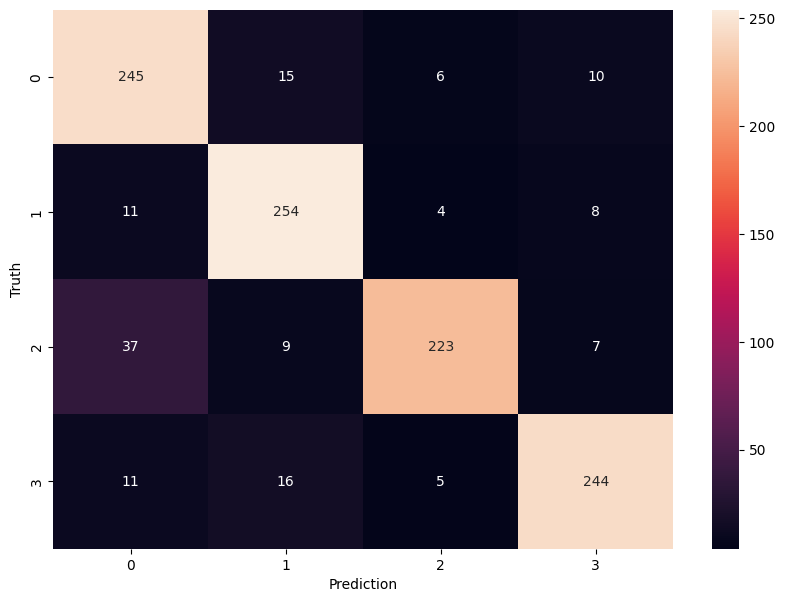

In [70]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')